# Online Retail Sales and Customer Analysis

This notebook provides basic data analysis on the Online Retail transaction dataset. It covers data cleaning, basic sales trends, rule-based customer grouping, monthly customer counts, and product co-occurrence mapping.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Set plotting options
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

print("Libraries loaded.")

Libraries loaded.


## 1. Data Cleaning

We load the transaction dataset and clean the records:
- Remove rows without customer IDs.
- Remove records where quantities or prices are zero or negative (returns and price adjustments).
- Remove identical duplicate rows.
- Compute the total revenue for each transaction line.

In [ ]:
df = pd.read_csv("../../online_retail.csv", encoding="latin1")
print(f"Raw dataset rows: {df.shape[0]}")

# 1. Drop rows missing CustomerID and convert types
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['StockCode'] = df['StockCode'].astype(str).str.strip()

# 2. Filter out returns and pricing corrections
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 3. Remove duplicate entries
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed duplicate records: {duplicate_count}")

# 4. Feature engineering
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceYearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Cleaned dataset rows (without duplicatetes, NA etc): {df.shape[0]}")
print(f"Summary (head)")
df.head()

Loading transaction data (Online Retail.xlsx)...


Raw dataset rows: 541909


Removed duplicate records: 5192
Cleaned dataset rows: 392692


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceYearMonth,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,20.34


## 2. Monthly Sales Trend and Top Products

We calculate monthly sales trends and examine the top 10 products by quantity sold using standard bar and line charts.

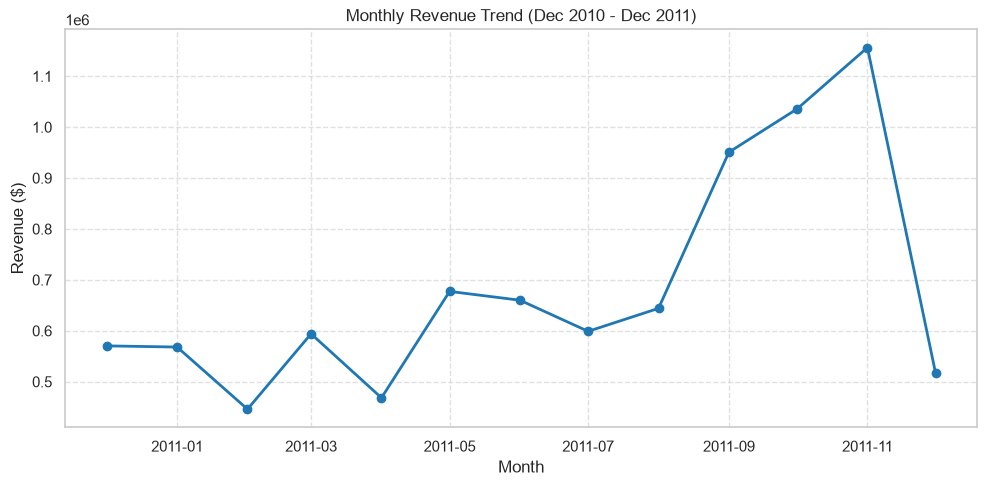

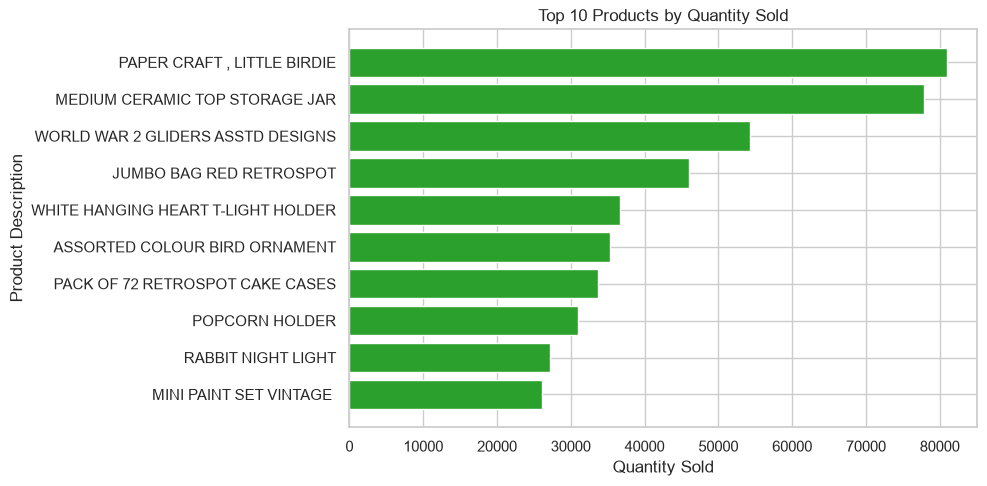

In [ ]:
# 1. Monthly Revenue Trend
monthly_trend = df.groupby('InvoiceYearMonth')['Revenue'].sum().reset_index()
monthly_trend['InvoiceYearMonth'] = monthly_trend['InvoiceYearMonth'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend['InvoiceYearMonth'], monthly_trend['Revenue'], marker='o', color='tab:blue', linewidth=2)
plt.title('Monthly Revenue Trend (Dec 2010 - Dec 2011)')
plt.xlabel('Month')
plt.ylabel('Revenue ($ in millions)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 2. Top 10 Best Selling Products by Quantity
top_items = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
plt.barh(top_items['Description'], top_items['Quantity'], color='tab:green')
plt.gca().invert_yaxis()  # invert list to show top seller on top
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

## 3. Rule-Based Customer Grouping

We group customers by computing their Recency (days since last purchase), Frequency (number of unique orders), and Monetary Value (total spend). We then classify them into three simple categories:
- **High Value**: Total spend > $2,000 and total unique orders >= 5.
- **Low Value (Inactive)**: Last purchase was more than 180 days ago.
- **Medium Value**: All other active customers.

Customer counts per category:
Category
Medium Value            2755
Low Value (Inactive)     854
High Value               729
Name: count, dtype: int64


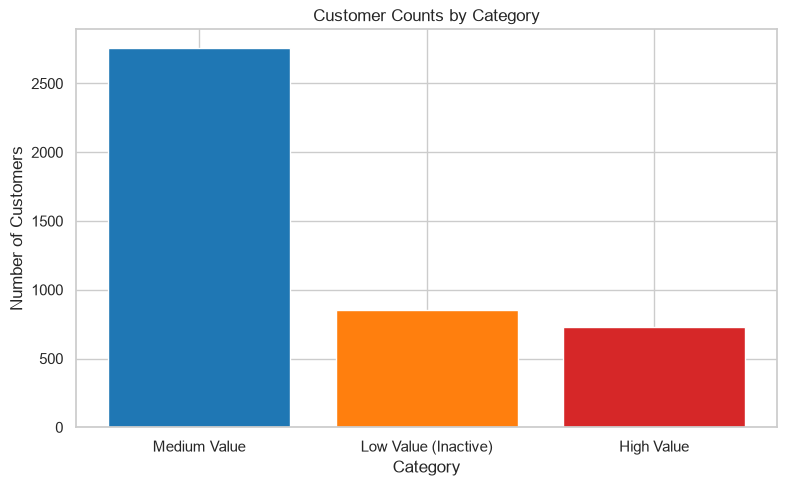

In [4]:
# Reference point is the day after the last invoice in the dataset
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Compute Recency, Frequency, and Monetary metrics per customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (ref_date - date.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Apply basic category logic
def categorize_customer(row):
    if row['Monetary'] > 2000 and row['Frequency'] >= 5:
        return 'High Value'
    elif row['Recency'] > 180:
        return 'Low Value (Inactive)'
    else:
        return 'Medium Value'

rfm['Category'] = rfm.apply(categorize_customer, axis=1)

# Summarize customer counts per category
category_counts = rfm['Category'].value_counts()
print("Customer counts per category:")
print(category_counts)

# Bar chart of category distribution
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values, color=['tab:blue', 'tab:orange', 'tab:red'])
plt.title('Customer Counts by Category')
plt.xlabel('Category')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## 4. Unique Active Customers by Month

We count the number of unique active customers who made at least one purchase in each month.

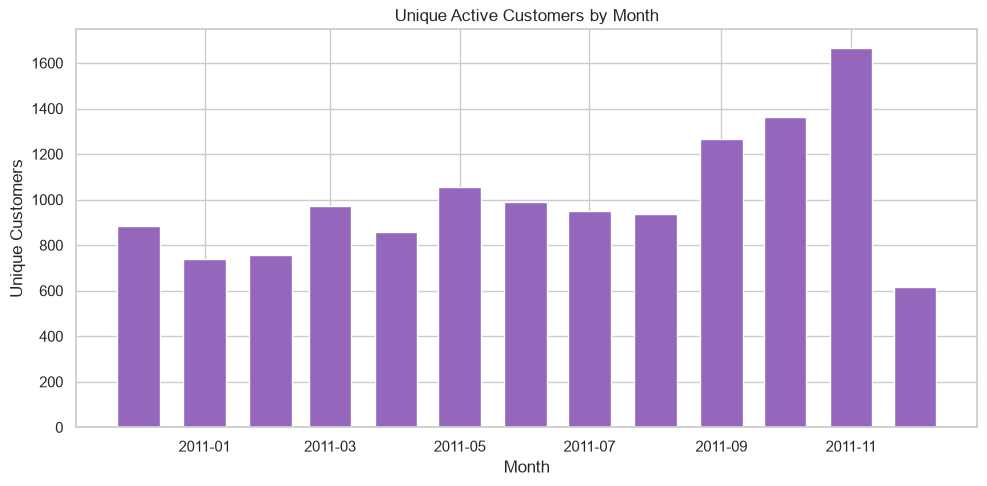

In [5]:
monthly_active = df.groupby('InvoiceYearMonth')['CustomerID'].nunique().reset_index()
monthly_active['InvoiceYearMonth'] = monthly_active['InvoiceYearMonth'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
plt.bar(monthly_active['InvoiceYearMonth'], monthly_active['CustomerID'], width=20, color='tab:purple')
plt.title('Unique Active Customers by Month')
plt.xlabel('Month')
plt.ylabel('Unique Customers')
plt.tight_layout()
plt.show()

## 5. Basic Product Associations

We identify which products are frequently purchased in the same invoice. We restrict the search to the top 100 selling items for clarity, list the overlapping pairs, and print the top 10 most common co-occurrences.

In [6]:
from collections import defaultdict
from itertools import combinations

# Select top 100 items by overall quantity
top_item_codes = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(100).index

# Build transactional basket sets (restricted to top 100 items)
baskets = df[df['StockCode'].isin(top_item_codes)].groupby('InvoiceNo')['StockCode'].apply(set).tolist()
baskets = [b for b in baskets if len(b) > 1]  # keep multi-item baskets

# Build a fast description lookup map
code_to_desc = df.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()

# Count co-occurrences for item pairs
pair_counts = defaultdict(int)
for b in baskets:
    sorted_items = sorted(list(b))
    for p in combinations(sorted_items, 2):
        pair_counts[p] += 1

# Find the top 10 most frequent pairs
top_pairs = sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 most frequent product co-occurrences:")
print("-" * 80)
for pair, count in top_pairs:
    desc1 = code_to_desc.get(pair[0], pair[0])
    desc2 = code_to_desc.get(pair[1], pair[1])
    print(f"{desc1}  AND  {desc2} (Co-occurrences: {count})")

Top 10 most frequent product co-occurrences:
--------------------------------------------------------------------------------
JUMBO BAG PINK POLKADOT  AND  JUMBO BAG RED RETROSPOT (Co-occurrences: 546)
LUNCH BAG RED RETROSPOT  AND  LUNCH BAG PINK POLKADOT (Co-occurrences: 523)
LUNCH BAG RED RETROSPOT  AND  LUNCH BAG SUKI  DESIGN  (Co-occurrences: 519)
LUNCH BAG RED RETROSPOT  AND  LUNCH BAG  BLACK SKULL. (Co-occurrences: 517)
JUMBO BAG DOILEY PATTERNS  AND  JUMBO BAG RED RETROSPOT (Co-occurrences: 468)
LUNCH BAG RED RETROSPOT  AND  LUNCH BAG SPACEBOY DESIGN  (Co-occurrences: 467)
LUNCH BAG  BLACK SKULL.  AND  LUNCH BAG SUKI  DESIGN  (Co-occurrences: 465)
LUNCH BAG  BLACK SKULL.  AND  LUNCH BAG PINK POLKADOT (Co-occurrences: 464)
LUNCH BAG RED RETROSPOT  AND  LUNCH BAG CARS BLUE (Co-occurrences: 459)
LUNCH BAG CARS BLUE  AND  LUNCH BAG SUKI  DESIGN  (Co-occurrences: 452)


**Data ethics primarily refers to the ethical and responsible use of data (which is generated in TBs everyday). Includes the collection, storage, processing and analysis of such data. All this is managed by some key processes in the industry using Transparency (where data originates from), Documentation (methodollogy), Bias Mitigation via audits and a diverse representation**